Chargement du fichier : data/raw/SMD/train/machine-1-1.txt
Shape final : (28479, 38)
✓ 38 features détectées avec succès !

=== Analyse pour identifier CPU, RAM, Réseau, etc. ===

Top 15 features triées par moyenne (les plus importantes souvent) :
              mean     std     min     max
feature_5   0.9136  0.0380  0.0000  1.0000
feature_22  0.6485  0.2857  0.0000  1.0000
feature_6   0.2623  0.0667  0.0000  0.3606
feature_15  0.1458  0.0391  0.0182  1.0000
feature_10  0.1300  0.0395  0.0000  1.0000
feature_14  0.0896  0.0371  0.0000  0.5650
feature_11  0.0870  0.0455  0.0000  0.7432
feature_18  0.0804  0.0397  0.0159  0.2980
feature_20  0.0658  0.0426  0.0107  0.3557
feature_0   0.0642  0.0567  0.0000  0.4946
feature_19  0.0619  0.0415  0.0100  0.3695
feature_1   0.0569  0.0425  0.0000  0.4216
feature_27  0.0549  0.0356  0.0090  0.2977
feature_2   0.0535  0.0377  0.0000  0.2787
feature_13  0.0512  0.0156  0.0038  0.1231


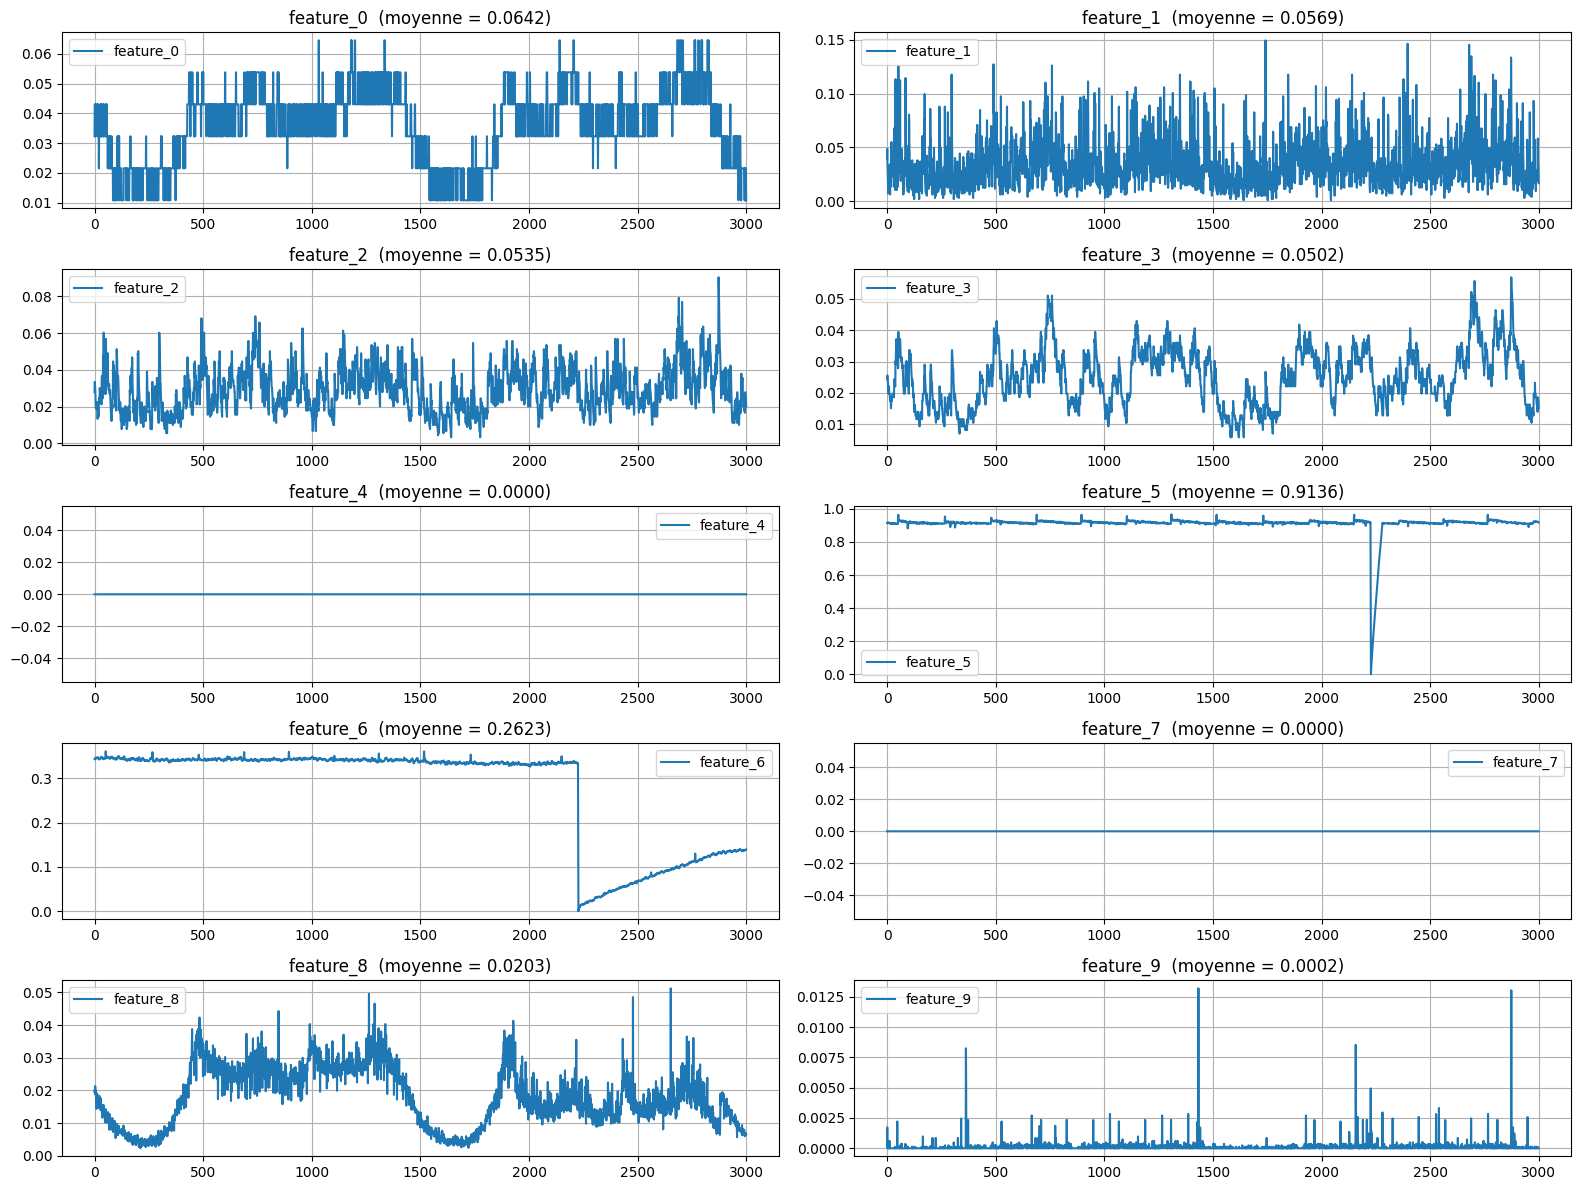


Features avec moyenne élevée (> 0.4) - Probablement RAM ou utilisation intensive :
              mean     std  min  max
feature_5   0.9136  0.0380  0.0  1.0
feature_22  0.6485  0.2857  0.0  1.0


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import os

DATA_PATH = 'data/raw/SMD/'
full_path = os.path.join(DATA_PATH, 'train/machine-1-1.txt')

print("Chargement du fichier :", full_path)

# Lecture + nettoyage automatique
with open(full_path, 'r') as f:
    lines = f.readlines()

# Nettoyage des lignes (remplace les virgules mal placées par des espaces)
cleaned_lines = []
for line in lines:
    line = line.strip()
    if line:  # ignorer les lignes vides
        line = line.replace(',', ' ')   # important pour ce dataset
        cleaned_lines.append(line + '\n')

# Sauvegarde temporaire du fichier nettoyé
temp_path = full_path + '.clean'
with open(temp_path, 'w') as f:
    f.writelines(cleaned_lines)

# Lecture finale avec le fichier nettoyé
df = pd.read_csv(temp_path, sep=r'\s+', header=None, engine='python')

# Nettoyage du fichier temporaire
os.remove(temp_path)

print(f"Shape final : {df.shape}")

# Assignation des noms de colonnes
if df.shape[1] == 38:
    df.columns = [f'feature_{i}' for i in range(38)]
    print("✓ 38 features détectées avec succès !")
else:
    print(f"⚠️ Problème : {df.shape[1]} colonnes au lieu de 38")

# ====================== ANALYSE DES FEATURES ======================
print("\n=== Analyse pour identifier CPU, RAM, Réseau, etc. ===\n")

stats = df.describe().T[['mean', 'std', 'min', 'max']]
stats = stats.round(4)
stats = stats.sort_values(by='mean', ascending=False)

print("Top 15 features triées par moyenne (les plus importantes souvent) :")
print(stats.head(15))

# Visualisation des 10 premières features
plt.figure(figsize=(16, 12))
for i in range(10):
    plt.subplot(5, 2, i+1)
    plt.plot(df.iloc[:3000, i], label=f'feature_{i}')
    plt.title(f'feature_{i}  (moyenne = {df.iloc[:, i].mean():.4f})')
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.show()

# Features avec moyenne très élevée → souvent RAM ou Disk usage
high_mean_features = stats[stats['mean'] > 0.4]
print("\nFeatures avec moyenne élevée (> 0.4) - Probablement RAM ou utilisation intensive :")
print(high_mean_features)

Chemin utilisé : data/raw/SMD/train/machine-1-1.txt
Fichier existe ? True
Shape après première lecture : (28479, 1)
Détection de données mal séparées → tentative de nettoyage...
✓ Dataset chargé avec succès (38 features)

=== SUCCESS - Dataset SMD chargé ! ===
Nombre de points temporels : 28,479
Nombre de métriques : 38

Aperçu des 5 premières lignes :
   feature_0  feature_1  feature_2  feature_3  feature_4  feature_5  \
0   0.032258   0.039195   0.027871   0.024390        0.0   0.915385   
1   0.043011   0.048729   0.033445   0.025552        0.0   0.915385   
2   0.043011   0.034958   0.032330   0.025552        0.0   0.915385   
3   0.032258   0.028602   0.030100   0.024390        0.0   0.912821   
4   0.032258   0.019068   0.026756   0.023229        0.0   0.912821   

   feature_6  feature_7  feature_8  feature_9  ...  feature_28  feature_29  \
0   0.343691        0.0   0.020011   0.000122  ...         0.0    0.004298   
1   0.344633        0.0   0.019160   0.001722  ...         0.0

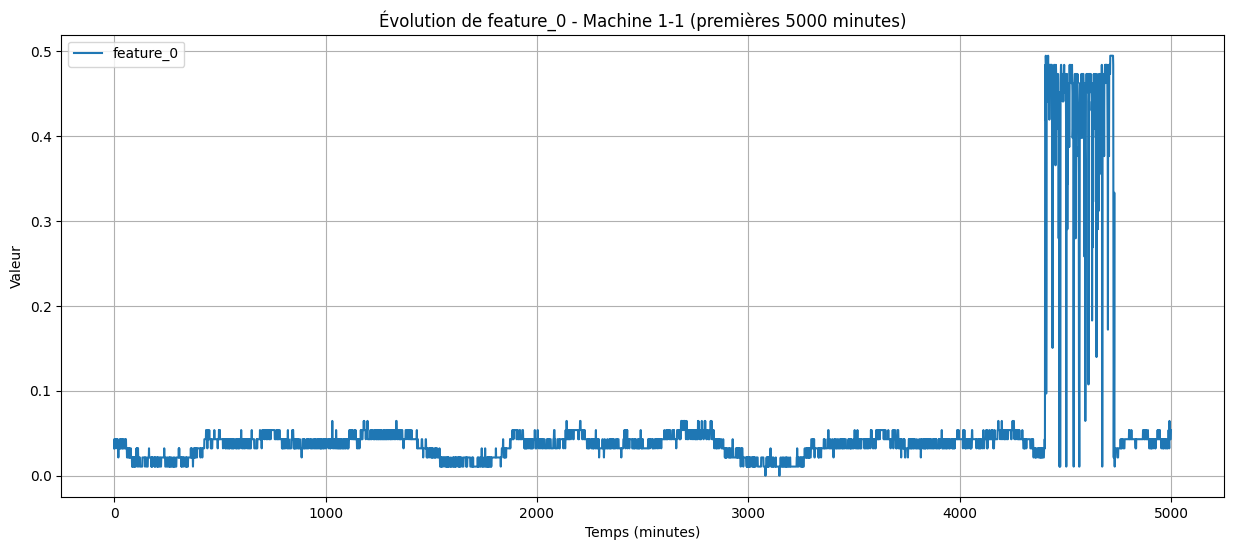

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Chemin du fichier
DATA_PATH = 'data/raw/SMD/'
train_file = 'train/machine-1-1.txt'
full_path = os.path.join(DATA_PATH, train_file)

print("Chemin utilisé :", full_path)
print("Fichier existe ?", os.path.exists(full_path))

# Lecture robuste du fichier SMD
try:
    # Première tentative : séparateur espaces multiples
    df_train = pd.read_csv(full_path, 
                           sep=r'\s+', 
                           header=None, 
                           engine='python',
                           on_bad_lines='skip')   # Ignore les lignes problématiques
    
    print(f"Shape après première lecture : {df_train.shape}")
    
    # Si on n'a qu'une seule colonne → c'est que les données sont mal séparées (virgules incluses)
    if df_train.shape[1] == 1:
        print("Détection de données mal séparées → tentative de nettoyage...")
        # On lit le fichier en texte et on remplace les virgules mal placées
        with open(full_path, 'r') as f:
            lines = f.readlines()
        
        cleaned_lines = []
        for line in lines:
            # Remplacer les virgules qui sont entre nombres par des espaces
            line = line.replace(',', ' ')
            cleaned_lines.append(line)
        
        # Sauvegarder temporairement la version nettoyée
        temp_path = full_path + '.clean'
        with open(temp_path, 'w') as f:
            f.writelines(cleaned_lines)
        
        df_train = pd.read_csv(temp_path, 
                               sep=r'\s+', 
                               header=None, 
                               engine='python')
        os.remove(temp_path)  # Supprimer le fichier temporaire
    
    # Assigner les noms de colonnes (38 features)
    if df_train.shape[1] == 38:
        df_train.columns = [f'feature_{i}' for i in range(38)]
        print("✓ Dataset chargé avec succès (38 features)")
    else:
        print(f"⚠️ Nombre de colonnes inattendu : {df_train.shape[1]} au lieu de 38")
    
    # Affichage des résultats
    print("\n=== SUCCESS - Dataset SMD chargé ! ===")
    print(f"Nombre de points temporels : {df_train.shape[0]:,}")
    print(f"Nombre de métriques : {df_train.shape[1]}")
    
    print("\nAperçu des 5 premières lignes :")
    print(df_train.head())
    
    print("\nStatistiques (6 premières features) :")
    print(df_train.describe().iloc[:, :6].round(4))

    # Graphique
    plt.figure(figsize=(15, 6))
    plt.plot(df_train.iloc[:5000, 0], label='feature_0')
    plt.title('Évolution de feature_0 - Machine 1-1 (premières 5000 minutes)')
    plt.xlabel('Temps (minutes)')
    plt.ylabel('Valeur')
    plt.legend()
    plt.grid(True)
    plt.show()

except Exception as e:
    print("Erreur lors du chargement :", str(e))

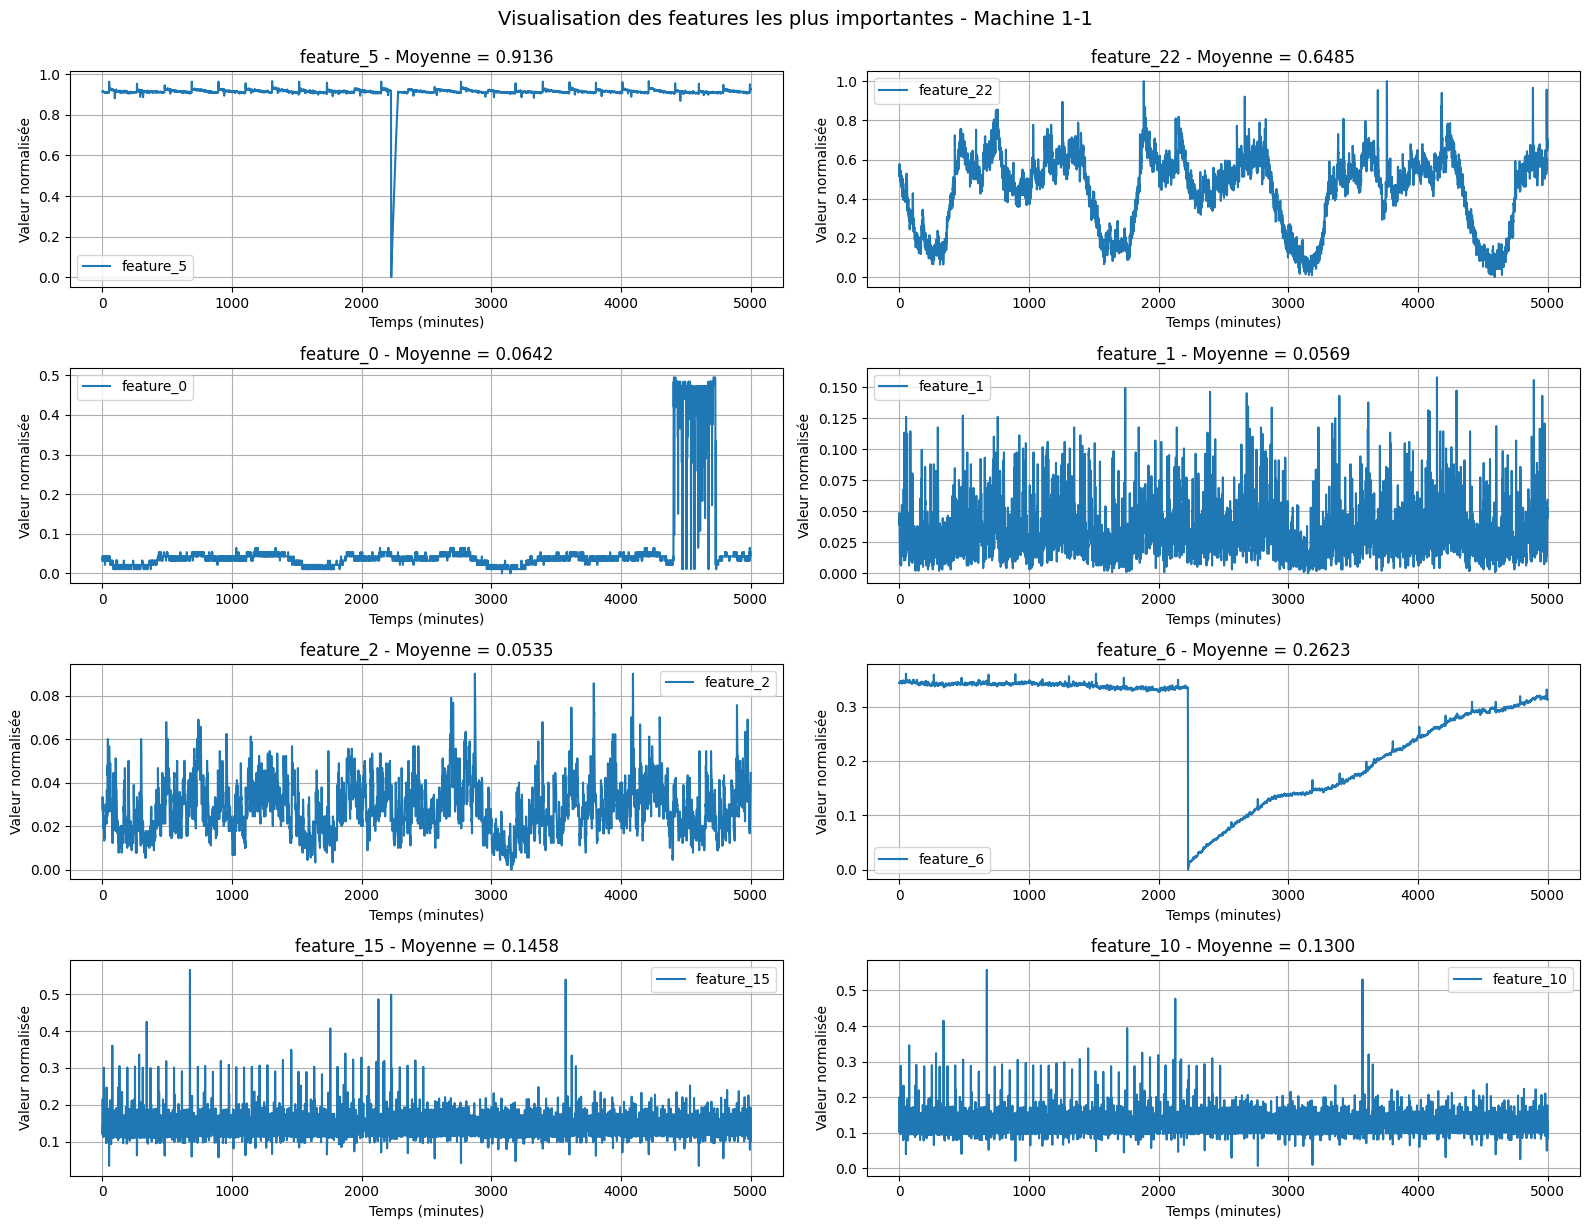

In [12]:
import matplotlib.pyplot as plt

# Features les plus intéressantes à visualiser
important_features = [5, 22, 0, 1, 2, 6, 15, 10]

plt.figure(figsize=(16, 12))

for idx, feat in enumerate(important_features):
    plt.subplot(4, 2, idx+1)
    plt.plot(df.iloc[:5000, feat], label=f'feature_{feat}')
    plt.title(f'feature_{feat} - Moyenne = {df.iloc[:, feat].mean():.4f}')
    plt.xlabel('Temps (minutes)')
    plt.ylabel('Valeur normalisée')
    plt.grid(True)
    plt.legend()

plt.tight_layout()
plt.suptitle('Visualisation des features les plus importantes - Machine 1-1', fontsize=14, y=1.02)
plt.show()